# Decoupling the likelihood from its gradient — KF / lofi-PF / hifi-PF

Back in the discrete-time LTI setting (one unknown transition coefficient $\alpha$, exact Kalman-filter marginal likelihood as ground truth). We now feed the sampler a log-density whose **value** and **gradient** come from *different* filters, chosen independently from

$$\text{source} \in \{\,\mathrm{KF\ (exact)},\ \mathrm{lofi\ PF}\ (100),\ \mathrm{hifi\ PF}\ (1000)\,\}.$$

A `jax.custom_jvp` returns the primal-source log-likelihood as the value and the grad-source score as the tangent. The PF sources use a fixed CRN key (one rough sample path) and their `jax.grad` is the Fisher-identity score (via `stop_gradient_resample`), not the path derivative of the estimate. The diagonal `primal == grad` cells are the ordinary targets (`KF/KF` is the exact gold standard); the off-diagonals mix a value of one fidelity with a score of another.

We illustrate the $(L, dL)$ surfaces per source, then sweep all 9 (primal, gradient) combinations and report W1-to-truth and ESS/s as $3\times 3$ heatmaps (NUTS vs WALNUTS), plus a $3\times 3$ grid of posterior histograms against the exact KF posterior.

In [1]:
import time
import warnings

warnings.filterwarnings("ignore")

import jax
jax.config.update("jax_enable_x64", True) 
import jax.numpy as jnp
import jax.random as jr
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import manual_combo_inference as mci
from manual_discrete_time_inference import simulate_lti_discrete_gaussian

%matplotlib inline

# --- data: mirror the discrete-time notebook (alpha*=0.4, T=100) ---
true_alpha = jnp.array(0.4)
obs_times = jnp.arange(0.0, 100.0, 1.0)
key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)
ctrl_values = jr.normal(key_ctrl, shape=(obs_times.shape[0], 1))

n_lofi, n_hifi = 100, 1000
pf_fixed_key = jr.PRNGKey(456)
system_kwargs = {"Q": 0.1 * jnp.eye(2), "R": jnp.array([[0.1 ** 2]])}

_, _, observations = simulate_lti_discrete_gaussian(
    key_data, alpha=true_alpha, times=obs_times,
    ctrl_values=ctrl_values, system_kwargs=system_kwargs,
)
obs_values = observations[:, None]

# Shared config for every source / combination.
cfg = dict(ctrl_values=ctrl_values, n_lofi=n_lofi, n_hifi=n_hifi,
           fixed_key=pf_fixed_key, system_kwargs=system_kwargs)

NUM_WARMUP = 200
NUM_SAMPLES = 1_000

# Exact KF posterior: ground truth for W1 and the histogram overlay.
ref_grid, ref_pdf = mci.kf_posterior_grid(
    obs_values, ctrl_values=ctrl_values, system_kwargs=system_kwargs
)
reference = mci.kf_posterior_reference_samples(
    obs_values, 0, 50_000, ctrl_values=ctrl_values, system_kwargs=system_kwargs
)
print("data ready; KF posterior mean=%.3f std=%.3f" % (reference.mean(), reference.std()))

data ready; KF posterior mean=0.431 std=0.087


## $(L, dL)$ surfaces by source

The value of a combination is read off its primal source's $L$; the gradient off its grad source's $dL$. KF is smooth/exact; the fixed-key PFs are rough, and rougher at low fidelity.

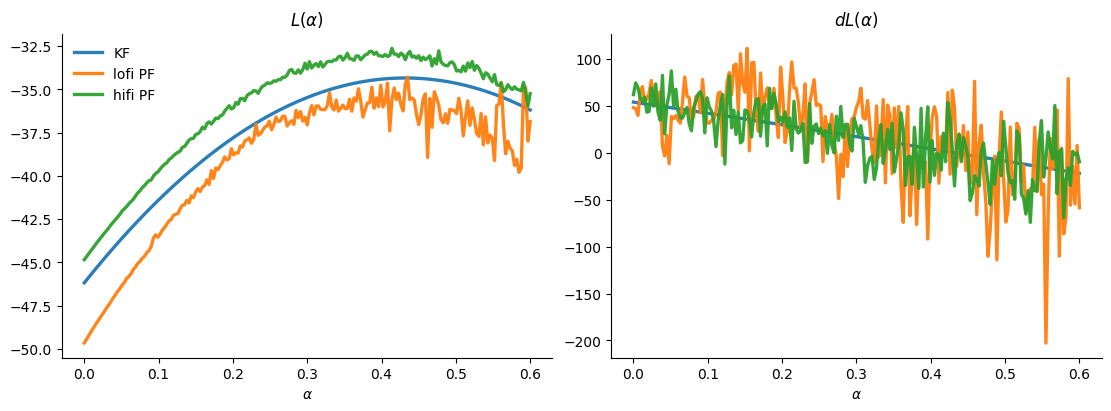

In [2]:
alpha_grid = jnp.linspace(0.0, 0.6, 201)
SRC = list(mci.SOURCES)                       # ["kf", "lofi", "hifi"]
labels = [mci.SOURCE_LABELS[s] for s in SRC]  # ["KF", "lofi PF", "hifi PF"]

loglik_by_source, score_by_source = [], []
for s in SRC:
    fn = mci.make_source_loglik(s, obs_values, **cfg)
    L, dL = jax.vmap(jax.value_and_grad(fn))(alpha_grid)
    loglik_by_source.append(np.asarray(L))
    score_by_source.append(np.asarray(dL))

fig, _ = mci.plot_loglik_score_curves(
    alpha_grid, loglik_by_source, score_by_source, labels=labels
)
plt.show()

## Grid over the 9 (primal, gradient) combinations

One NUTS and one fork-WALNUTS run per combination. The `grad = hifi PF` column is the expensive one (each leapfrog step differentiates a 1000-particle filter), and some combinations make inference collapse and run effectively forever.

To bound that, **each method runs in a separate process with a hard 3-minute timeout**. Post-warmup samples are streamed out (and survive the kill), so a slow combination returns whatever chain it managed to draw; a combination that never clears warmup returns `NaN`. The W1 / ESS-per-s heatmaps and the histograms mark those `NaN`/empty cells explicitly.

In [3]:
TIMEOUT_S = 60.0 * 2  # 5 minutes per method (per combination, per sampler, per replica)
RUN_WALNUTS = False  # set False to run NUTS only (drops the WALNUTS column everywhere)
N_REPLICAS = 3      # independent seeds per (combination, sampler) to test reproducibility


def metrics_from_samples(samples, elapsed):
    # W1-to-truth and ESS/s from whatever samples survived the timeout; NaN if the
    # method did not get out of warmup (samples is None) or produced too few draws.
    if samples is None or len(samples) < 2:
        return np.nan, np.nan
    try:
        w1 = mci.wasserstein1_to_truth(samples, reference)
    except Exception:
        w1 = np.nan
    try:
        ess = float(np.asarray(az.ess(np.asarray(samples).ravel()[None, :])))
        essps = ess / elapsed if elapsed > 0 else np.nan
    except Exception:
        essps = np.nan
    return w1, essps


def is_failure(samples):
    # A replica "fails" if it never produced a usable chain: timed out at/before
    # warmup, or returned fewer than 2 post-warmup draws.
    return samples is None or len(samples) < 2


# sampler -> extra warmup/kernel kwargs (WALNUTS included only when RUN_WALNUTS)
sampler_specs = {"nuts": {}}
if RUN_WALNUTS:
    sampler_specs["walnuts"] = dict(
        initial_step_size=1e-1, max_num_doublings=5, max_num_micro_doublings=4
    )

# W1 / ESS are averaged over the successful replicas; `failures` counts the rest.
W1 = {k: np.full((3, 3), np.nan) for k in sampler_specs}
ESS = {k: np.full((3, 3), np.nan) for k in sampler_specs}
failures = {k: np.zeros((3, 3), dtype=int) for k in sampler_specs}
combo_samples = {k: {} for k in sampler_specs}  # pooled successful-replica draws

# Each replica runs in a separate process with a hard TIMEOUT_S budget; post-warmup
# samples are streamed out and survive a kill, so a collapsing combo returns its
# partial chain (or NaN if it never cleared warmup) instead of hanging the notebook.
seed = 100
for i, p in enumerate(tqdm(SRC)):
    for j, g in enumerate(tqdm(SRC, leave=False)):
        for name, kw in sampler_specs.items():
            w1s, ess_rates, pooled, n_fail = [], [], [], 0
            for rep in range(N_REPLICAS):
                res = mci.run_combo_with_timeout(
                    name, p, g,
                    obs_values=obs_values, ctrl_values=ctrl_values, system_kwargs=system_kwargs,
                    n_lofi=n_lofi, n_hifi=n_hifi, fixed_key=pf_fixed_key,
                    seed=seed, init_position=0.35,
                    num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
                    sampler_kwargs=kw, timeout_s=TIMEOUT_S,
                )
                seed += 1
                s = res["samples"]
                failed = is_failure(s)
                if failed:
                    n_fail += 1
                else:
                    w1, essps = metrics_from_samples(s, res["elapsed"])
                    w1s.append(w1)
                    ess_rates.append(essps)
                    pooled.append(np.asarray(s))
                tqdm.write(
                    f"{name:7s} primal={p:4s} grad={g:4s} rep={rep} | "
                    f"warmup_done={res['warmup_done']} n_samples={0 if s is None else len(s):4d} "
                    f"elapsed={res['elapsed']:5.0f}s failed={failed}"
                )
            failures[name][i, j] = n_fail
            if w1s:
                W1[name][i, j] = float(np.nanmean(w1s))
                ESS[name][i, j] = float(np.nanmean(ess_rates))
                combo_samples[name][(p, g)] = np.concatenate(pooled)
            else:
                combo_samples[name][(p, g)] = None

                                     
  0%|          | 0/3 [00:06<?, ?it/s]

nuts    primal=kf   grad=kf   rep=0 | warmup_done=True n_samples=1000 elapsed=    6s failed=False


                                     
  0%|          | 0/3 [00:10<?, ?it/s]

nuts    primal=kf   grad=kf   rep=1 | warmup_done=True n_samples=1000 elapsed=    4s failed=False


                                     
  0%|          | 0/3 [00:15<?, ?it/s]

...

nuts    primal=hifi grad=hifi rep=0 | warmup_done=True n_samples=   2 elapsed=  120s failed=False


                                              
 67%|██████▋   | 2/3 [39:22<14:07, 847.42s/it]

nuts    primal=hifi grad=hifi rep=1 | warmup_done=True n_samples=  53 elapsed=  120s failed=False


                                              
100%|██████████| 3/3 [41:22<00:00, 827.37s/it]

nuts    primal=hifi grad=hifi rep=2 | warmup_done=True n_samples=   0 elapsed=  120s failed=True


## W1 to truth — rows = primal (value) source, cols = gradient (score) source

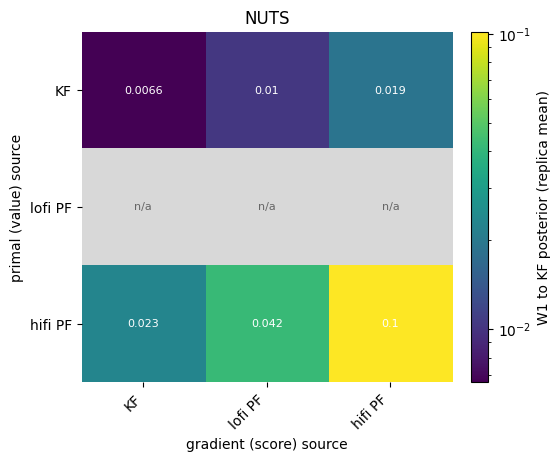

In [4]:
fig, _ = mci.plot_combo_heatmaps(
    W1["nuts"], W1.get("walnuts"),
    primal_sources=labels, grad_sources=labels,
    quantity_label="W1 to KF posterior (replica mean)", log_color=True,
)
plt.show()

## ESS / s

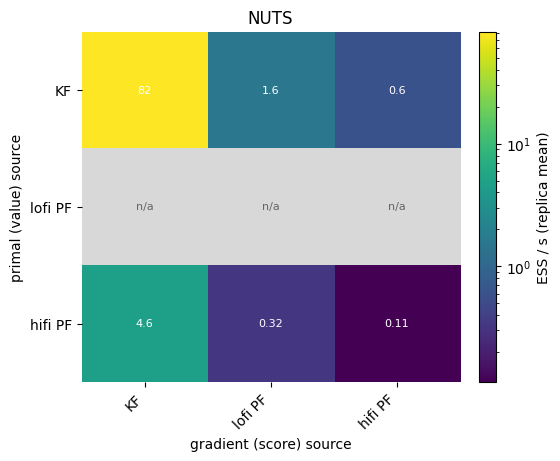

In [5]:
fig, _ = mci.plot_combo_heatmaps(
    ESS["nuts"], ESS.get("walnuts"),
    primal_sources=labels, grad_sources=labels,
    quantity_label="ESS / s (replica mean)", log_color=True,
)
plt.show()

## Posterior histograms ($3\times3$) — NUTS

Each cell: posterior samples (bars) vs the exact KF posterior (line); dashed line is $\alpha_\star = 0.4$.

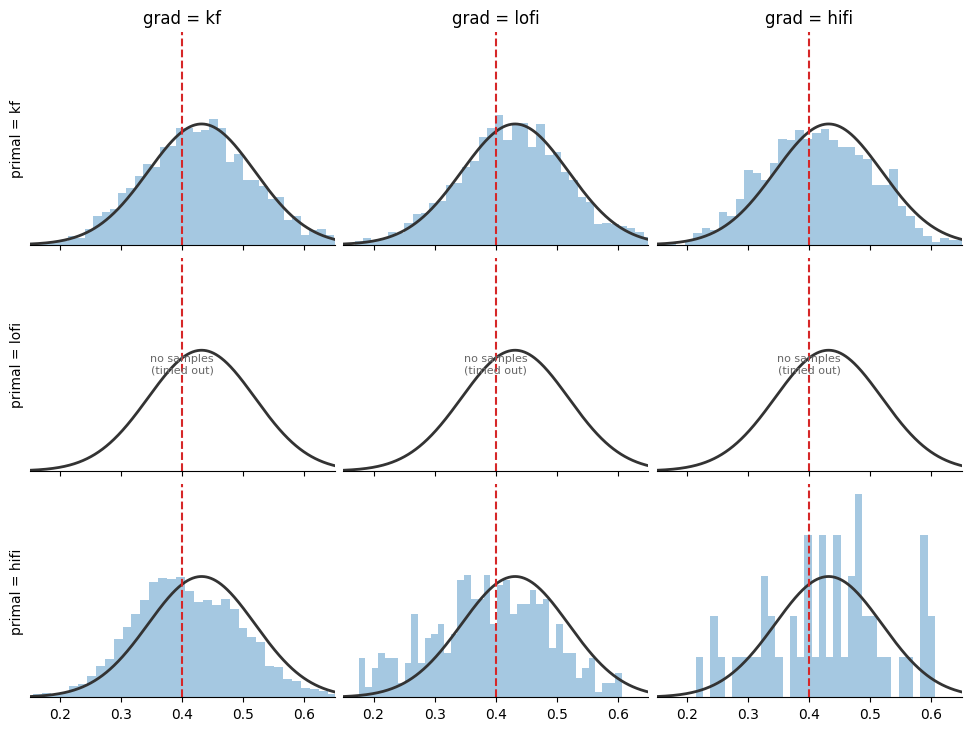

In [6]:
fig, _ = mci.plot_combo_histograms(
    combo_samples["nuts"], primal_sources=SRC, grad_sources=SRC,
    ref_grid=ref_grid, ref_pdf=ref_pdf, true_alpha=float(true_alpha), xlim=(0.15, 0.65),
)
plt.show()

## Posterior histograms ($3\times3$) — WALNUTS

In [7]:
if "walnuts" in combo_samples:
    fig, _ = mci.plot_combo_histograms(
        combo_samples["walnuts"], primal_sources=SRC, grad_sources=SRC,
        ref_grid=ref_grid, ref_pdf=ref_pdf, true_alpha=float(true_alpha), xlim=(0.15, 0.65),
    )
    plt.show()
else:
    print("WALNUTS not run (RUN_WALNUTS = False).")

WALNUTS not run (RUN_WALNUTS = False).


## Failures across replicas

How many of the `N_REPLICAS` seeds failed to produce a usable chain (timed out at/before
warmup, or fewer than 2 draws) per (primal, gradient) combination. `0` means every replica
produced samples; the W1 / ESS heatmaps above are averaged over the non-failing replicas.

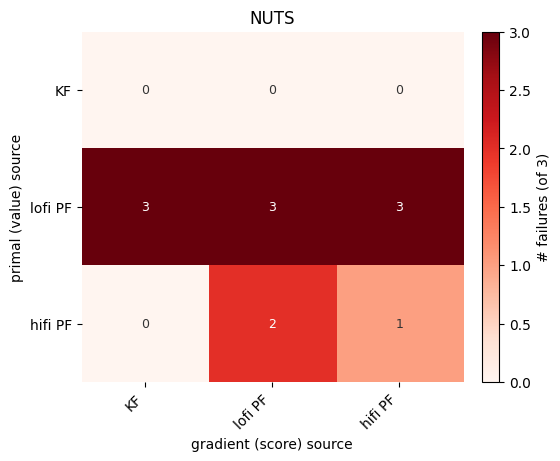

In [8]:
fig, _ = mci.plot_combo_failures(
    failures, primal_sources=labels, grad_sources=labels, n_replicas=N_REPLICAS
)
plt.show()